# Q-learning

In this notebook, you will implement Q-learning as described in [Sutton and Barto's book, Introduction to Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html). We will use the grid ```World``` class from the previous lectures. 

### Install dependencies

In [1]:
! pip install numpy pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\chris\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Imports

In [13]:
import numpy as np
import random
import sys  # We use sys to get the max value of a float
import pandas as pd  # We only use pandas for displaying tables nicely
import matplotlib.pyplot as plt
pd.options.display.float_format = '{:,.3f}'.format

### ```World``` class and globals

The ```World``` is a grid represented as a two-dimensional array of characters where each character can represent free space, an obstacle, or a terminal. Each non-obstacle cell is associated with a reward that an agent gets for moving to that cell (can be 0). The size of the world is _width_ $\times$ _height_ characters.

A _state_ is a tuple $(x,y)$.

An empty world is created in the ```__init__``` method. Obstacles, rewards and terminals can then be added with ```add_obstacle``` and ```add_reward```.

To calculate the next state of an agent (that is, an agent is in some state $s = (x,y)$ and performs and action, $a$), ```get_next_state()```should be called.

In [3]:
# Globals:
ACTIONS = ("up", "down", "left", "right") 

# Rewards, terminals and obstacles are characters:
REWARDS = {" ": -1, ".": 0.1, "+": 10, "-": -10}
TERMINALS = ("+", "-") # Note a terminal should also have a reward assigned
OBSTACLES = ("#")

# Discount factor
gamma = 1

# The probability of a random move:
rand_move_probability = 0

class World:  
  def __init__(self, width, height):
    self.width = width
    self.height = height
    # Create an empty world where the agent can move to all cells
    self.grid = np.full((width, height), ' ', dtype='U1')
  
  def add_obstacle(self, start_x, start_y, end_x=None, end_y=None):
    """
    Create an obstacle in either a single cell or rectangle.
    """
    if end_x == None: end_x = start_x
    if end_y == None: end_y = start_y
    
    self.grid[start_x:end_x + 1, start_y:end_y + 1] = OBSTACLES[0]

  def add_reward(self, x, y, reward):
    assert reward in REWARDS, f"{reward} not in {REWARDS}"
    self.grid[x, y] = reward

  def add_terminal(self, x, y, terminal):
    assert terminal in TERMINALS, f"{terminal} not in {TERMINALS}"
    self.grid[x, y] = terminal

  def is_obstacle(self, x, y):
    if x < 0 or x >= self.width or y < 0 or y >= self.height:
      return True
    else:
      return self.grid[x ,y] in OBSTACLES 

  def is_terminal(self, x, y):
    return self.grid[x ,y] in TERMINALS

  def get_reward(self, x, y):
    """ 
    Return the reward associated with a given location
    """ 
    return REWARDS[self.grid[x, y]]

  def get_next_state(self, current_state, action):
    """
    Get the next state given a current state and an action. The outcome can be
    stochastic  where rand_move_probability determines the probability of 
    ignoring the action and performing a random move.
    """    
    assert action in ACTIONS, f"Unknown acion {action} must be one of {ACTIONS}"
    
    x, y = current_state 
    
    # If our current state is a terminal, there is no next state
    if self.grid[x, y] in TERMINALS:
      return None

    # Check of a random action should be performed:
    if np.random.rand() < rand_move_probability:
      action = np.random.choice(ACTIONS)

    if action == "up":      y -= 1
    elif action == "down":  y += 1
    elif action == "left":  x -= 1
    elif action == "right": x += 1

    # If the next state is an obstacle, stay in the current state
    return (x, y) if not self.is_obstacle(x, y) else current_state


## A simple world

In [4]:
world = World(4, 6)

# Since we only focus on episodic tasks, we must have a terminal state that the 
# agent eventually reaches
world.add_terminal(3, 5, "+")

print(world.grid.T)

[[' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' '+']]


In [40]:
def q_visualizer(world : World, q : np.ndarray) -> None:
    new_q = np.full((world.width, world.height), "", dtype=object)
    action_symbols = {
        'up': '↑',
        'down': '↓', 
        'left': '←',
        'right': '→'
    }
    for x in range(world.width):
        for y in range(world.height):
            if world.is_terminal(x, y):
                if world.get_reward(x, y) > 0:
                    new_q[x, y] = '+'
                elif world.get_reward(x, y) < 0:
                    new_q[x, y] = '-'
            elif world.is_obstacle(x, y):
                new_q[x, y] = '#'
            elif np.all(q[x, y, :] == 0.0):
                new_q[x, y] = ' '
            else:
                new_q[x, y] = action_symbols[ACTIONS[np.argmax(q[x, y, :])]]

    print("Best action at each state (arrows show direction):")
    display(pd.DataFrame(new_q.T))

## Exercise: Q-learning

Implement and test Q-learning. You should be able to base much of your code on your implementation of SARSA. Since Q-learning is an off-policy method, we can use whatever behavior policy we want during training, but the choice of behavioral policy still manners so it is a good idea to balance exploration and exploitation. During testing, we can then use the learnt policy (the target policy).

As for the behavior policy, you can use an simple $\epsilon$-greedy policy, but you can also experiment with alternatives, for instance, optimistic initial values. 

See page 131 in [Introduction to Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html) for the Q-learning algorithm. 


In [46]:
def q_learning(world, start_state, alpha=0.5, gamma=0.9, epsilon=0.1, episodes=10000):
    Q_table = np.full((world.width, world.height, len(ACTIONS)), 0.0) # Q_table[x, y, a_idx]
    
    policy = lambda state, q_func=Q_table : {k : 1-epsilon+epsilon/len(ACTIONS) 
                                             if k == ACTIONS[np.argmax(q_func[*state, :])] 
                                             else epsilon/len(ACTIONS) for k in ACTIONS}
    for _ in range(episodes):
        current_state = start_state
        next_state = None
        while not world.is_terminal(*current_state):
            action_prob = policy(current_state)
            action = random.choices(population=list(action_prob.keys()),
                                    weights=action_prob.values(), k=1)[0]
            action_idx = ACTIONS.index(action)
            next_state = world.get_next_state(current_state, ACTIONS[action_idx])
            next_action_idx = np.argmax(Q_table[*next_state, :]) # max(A_q_value)
            reward = world.get_reward(*next_state)
            
            if world.is_terminal(*next_state): # if next state is None (terminal) then break
                Q_table[*current_state, action_idx] += alpha * (reward - Q_table[*current_state, action_idx])
                break

            Q_current = Q_table[*current_state, action_idx]    # Q(S, A)
            Q_next_max = Q_table[*next_state, next_action_idx] # Q(S', max(A_q_value))
            Q_table[*current_state, action_idx] += alpha * (reward + gamma * Q_next_max - Q_current)

            current_state = next_state
    return Q_table


In [48]:
REWARDS = {" ": -1, "#": -1, "+": 10, "-": -10}

big_map = World(10, 10)
big_map.add_terminal(9, 0, "+")
big_map.add_terminal(9, 9, "+")
big_map.add_terminal(0, 9, "+")
big_map.add_terminal(0, 0, "+")
obstacles = [(1, 1), (2, 1), (3, 1), (7, 0), (2, 2), (2, 3), (7, 2), (7, 3), (2, 8), (2, 9), (7, 7), (7, 8)]
for x, y in obstacles:
    big_map.add_obstacle(x, y)

display(pd.DataFrame(big_map.grid.T))
q_q_learning = q_learning(big_map, (5,5))
q_visualizer(big_map, q_q_learning)
# q_world_small = World(2, 3)
# q_world_small.add_terminal(1, 2, "+")

# display(pd.DataFrame(q_world_small.grid.T))
# q_small = q_learning(q_world_small, (0, 0), episodes=1000)
# q_visualizer(q_world_small, q_small)

# q_world_big = World(10, 7)
# q_world_big.add_terminal(9, 6, "+")
# q_world_big.add_terminal(0, 6, "+")
# q_world_big.add_terminal(9, 0, "+")

# display(pd.DataFrame(q_world_big.grid.T))
# q_big = q_learning(q_world_big, (0, 0), episodes=100000)
# q_visualizer(q_world_big, q_big)

,0,1,2,3,4,5,6,7,8,9
0,+,,,,,,,#,,+
1,,#,#,#,,,,,,
2,,,#,,,,,#,,
3,,,#,,,,,#,,
4,,,,,,,,,,
5,,,,,,,,,,
6,,,,,,,,,,
7,,,,,,,,#,,
8,,,#,,,,,#,,
9,+,,#,,,,,,,+


Best action at each state (arrows show direction):


,0,1,2,3,4,5,6,7,8,9
0,+,←,←,←,←,↓,↓,#,→,+
1,↑,#,#,#,←,→,→,→,→,↑
2,↑,←,#,↑,↑,→,↑,#,↑,↑
3,↑,←,#,↓,←,→,↑,#,→,↑
4,↑,↓,←,←,←,→,→,→,↑,↑
5,↓,↓,←,←,←,↓,↓,↓,↓,↓
6,↓,←,←,←,←,↓,↓,→,↓,↓
7,↓,←,←,↑,→,↓,↓,#,↓,↓
8,↓,←,#,↑,↓,↓,↓,#,↓,↓
9,+,←,#,→,→,→,→,→,→,+


## Exercise: Compare Q-learning and SARSA

Setup experiments to compare the performance of Q-learning and SARSA. You can use different ```Worlds``` and test different parameter setting, e.g. for $\alpha$ and $\epsilon$. 

In [56]:
def sarsa(world, start_state, alpha=0.5, gamma=0.9, epsilon=0.1, episodes=10000):
    Q_table = np.full((world.width, world.height, len(ACTIONS)), 0.0) # Q_table[x, y, a_idx]
    
    policy = lambda state, q_func=Q_table : {k : 1-epsilon+epsilon/len(ACTIONS) 
                                             if k == ACTIONS[np.argmax(q_func[*state, :])] 
                                             else epsilon/len(ACTIONS) for k in ACTIONS}
    for _ in range(episodes):
        current_state = start_state
        next_state = None
        action_prob = policy(current_state)
        action = random.choices(population=list(action_prob.keys()),
                                    weights=action_prob.values(), k=1)[0]

        while not world.is_terminal(*current_state):
            next_state = world.get_next_state(current_state, action)
            reward = world.get_reward(*next_state)
            next_action_prob = policy(next_state)
            next_action = random.choices(population=list(next_action_prob.keys()),
                                    weights=next_action_prob.values(), k=1)[0]
            next_action_idx = ACTIONS.index(next_action)
            action_idx = ACTIONS.index(action)
            if world.is_terminal(*next_state): # if next state is None (terminal) then break
                Q_table[*current_state, action_idx] += alpha * (reward - Q_table[*current_state, action_idx])
                break
            
            Q_current = Q_table[*current_state, action_idx] # Q(S, A)
            Q_next = Q_table[*next_state, next_action_idx]  # Q(S', A')
            Q_table[*current_state, action_idx] += alpha * (reward + gamma * Q_next - Q_current)

            current_state = next_state
            action = next_action

    return Q_table


In [ ]:

REWARDS = {" ": 0, "#": -1, "+": 10, "-": -10}

big_map = World(10, 10)
big_map.add_terminal(9, 0, "+")
big_map.add_terminal(9, 9, "+")
big_map.add_terminal(0, 9, "+")
big_map.add_terminal(0, 0, "+")
obstacles = [(1, 1), (2, 1), (3, 1), (7, 0), (2, 2), (2, 3), (7, 2), (7, 3), (2, 8), (2, 9), (7, 7), (7, 8)]
for x, y in obstacles:
    big_map.add_obstacle(x, y)

display(pd.DataFrame(big_map.grid.T))
q_q_sarsa = sarsa(world=big_map, start_state=(5,5), alpha=0.5, gamma=0.9, epsilon=0.1, episodes=10000)
q_visualizer(big_map, q_q_sarsa)

# REWARDS = {" ": -1, ".": 0.1, "+": 10, "-": -10}
# world_big = World(10, 7)
# world_big.add_terminal(9, 6, "+")
# # world_big.add_terminal(0, 6, "+")
# # world_big.add_terminal(9, 0, "+")
# world_big.add_terminal(5, 3, "-")

# big map test
# REWARDS = {" ": -1, ".": 5, "+": 10, "-": -10}

# world_big = World(10, 10)
# world_big.add_terminal(9, 0, "+")
# world_big.add_terminal(9, 9, "+")
# world_big.add_terminal(9, 1, "-")
# world_big.add_terminal(9, 8, "-")
# obstacles = [(1, 1), (2, 1), (3, 1), (7, 0), (2, 2), (2, 3), (7, 2), (7, 3), (2, 8), (2, 9), (7, 7), (7, 8)]
# for x, y in obstacles:
#     world_big.add_obstacle(x, y)

# display(pd.DataFrame(world_big.grid.T))

# epsilon = 0.1

# print("SARSA")
# q_sarsa = sarsa(world_big, (0, 0), episodes=10000, epsilon=epsilon)
# q_visualizer(world_big, q_sarsa)

# print("Q-learning")
# q_learning1 = q_learning(world_big, (0, 0), episodes=10000, epsilon=epsilon)
# q_visualizer(world_big, q_learning1)

,0,1,2,3,4,5,6,7,8,9
0,+,,,,,,,#,,+
1,,#,#,#,,,,,,
2,,,#,,,,,#,,
3,,,#,,,,,#,,
4,,,,,,,,,,
5,,,,,,,,,,
6,,,,,,,,,,
7,,,,,,,,#,,
8,,,#,,,,,#,,
9,+,,#,,,,,,,+


Best action at each state (arrows show direction):


,0,1,2,3,4,5,6,7,8,9
0,+,←,←,←,←,←,←,#,→,+
1,↑,#,#,#,↑,←,←,←,↑,
2,↑,←,#,→,↑,↑,↑,#,,
3,,↑,#,↑,↑,↑,↑,#,,
4,,↑,→,↑,↑,↑,←,←,,
5,,,↑,↑,↑,↑,↑,↑,,
6,,,,↑,↑,↑,↑,,,
7,,,,,↑,↑,↑,#,,
8,,,#,,,↑,,#,,
9,+,,#,,,,,,,+


## Optional exercise: Maximization Bias and Double Learning

Below is an implementation of the task shown in Example 6.7 on page 134 in [Introduction to Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html). There are two states, ```A``` and ```B``` where the agent can perform actions, and a terminal state ```T```. ```A``` and ```B``` have different actions available:

* ```A``` has ```left``` (to ```B```) and ```right``` to the terminal state
* ```B``` has a larger number of actions all leading to a terminal state. 


In [3]:
# States "A" and "B" have actions while "T" is a terminal state.
STATES = ("A", "B", "T")

class Example67MDP: # we live here now
    def __init__(self, number_of_B_actions):
        """
        Create an example and set the number of outgoing actions for state "B"
        (in the book, they do not give a specific number, but merely write that 
        from "B" there "are many possible actions all of which cause immediate
        termination with a reward drawn from a normal distribution with mean 
        -0.1 and variance 1. So, feel free to play with different number of 
        actions in state B)
        
        """ 
        self.number_of_B_actions = number_of_B_actions

    def get_actions(self, state):
        """
        Returns the set of actions availabe in a given state (a tuple 
        with strings).  
        """
        assert state in STATES, f"State must be one of {STATES}, not {state}"
        if state == "A":
            return ("left", "right")
        if state == "B":
            return tuple(f"{i}" for i in range(self.number_of_B_actions))
        if state == "T":
            return tuple("N")

    def get_next_state_and_reward(self, state, action):
        """
        Get the next state and reward given a current state and an action
        """
        assert state in STATES, f"Unknown state: {state}"
        assert action in self.get_actions(state), f"Unknown action {action} for state {state}"
         
        if state == "T":
            raise Exception("The terminal state has no actions and no next state")

        if state == "A":
            if action == "right":
                return "T", 0
            if action == "left":
                return "B", 0

        if state == "B":
            return "T", np.random.normal(loc = -0.1)

    def is_terminal(self, state):
        assert state in STATES, f"Unknown state: {state}"
        return state == "T"


Implement Double Q-learning (see page 136 in [Introduction to Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html)) and test it on the ```Example67MDP``` above. Notice, that the number of actions differs between the two states ($\mathcal{A}$(```"A"```) $\neq \mathcal{A}$(```"B"```)), which you have to take into account in your Q-tables. See the code for ```Example67MDP``` above: you can get the set of actions available in a given state by calling ```get_actions(...)``` with the state as argument.

Compare action-value estimates for ```"left"``` and ```"right"``` in state ```"A"```  at different times during learning when using double-Q learning and when using normal Q-learning.

In [12]:
# Create an instance of Example 6.7 with 10 actions in B
example = Example67MDP(10)

gamma = 1
alpha = 0.05

# Create two Q-tables (feel free to use your own representation):
Q1 = [[0 for _ in range(len(example.get_actions(state)))] for state in STATES]
Q2 = [[0 for _ in range(len(example.get_actions(state)))] for state in STATES]

# Uncomment to disable double-Q-learning:
#Q2 = Q1

# You can use the below policy method if you use the Q1 and Q2 as defined above. 
# If you have done your own representation, you probably have to modify or 
# rewrite the function below:

def e_greedy_dql_policy(state):
  global example
  actions = { a:epsilon/len(example.get_actions(state)) for a in example.get_actions(state) }
  # Do a Q1 + Q2 to do epsilon greedy based on both tables:
  Q = [sum(x) for x in zip(Q1[STATES.index(state)], Q2[STATES.index(state)])]
  actions[example.get_actions(state)[np.argmax(Q)]] = 1 - epsilon + epsilon/len(example.get_actions(state))
  return actions


NameError: name 'Example67MDP' is not defined

Here is the Double Q

In [10]:
def double_q_learning(mdp, start_state, alpha=0.5, gamma=0.9, epsilon=0.1, episodes=1000, use_double=False):
    Q1_table = [[0 for _ in range(len(example.get_actions(state)))] for state in STATES]
    Q2_table = [[0 for _ in range(len(example.get_actions(state)))] for state in STATES]
    left = 0
    right = 0
    
    if not use_double:
        Q2_table = Q1_table

    def policy(state):
        actions = { a:epsilon/len(mdp.get_actions(state)) for a in mdp.get_actions(state) }
        Q = [sum(x) for x in zip(Q1_table[STATES.index(state)], Q2_table[STATES.index(state)])]
        actions[mdp.get_actions(state)[np.argmax(Q)]] = 1 - epsilon + epsilon/len(mdp.get_actions(state))
        return actions
    

    
    for _ in range(episodes):
        current_state = start_state
        next_state = None

        while not mdp.is_terminal(current_state):
            action_probs = policy(current_state)
            action = np.random.choice(list(action_probs.keys()), p=list(action_probs.values()))  # Sample action
            action_idx = list(mdp.get_actions(current_state)).index(action)
            next_state, reward = mdp.get_next_state_and_reward(current_state, action)
            if action == "left":
                left += 1
            else:
                right += 1
            if random.random() >= 0.5:
                Q1_max_action_idx = np.argmax(Q1_table[STATES.index(next_state)])
                Q1_SA = Q1_table[STATES.index(current_state)][action_idx]
                Q1_TD_error = reward + gamma * Q2_table[STATES.index(next_state)][Q1_max_action_idx] - Q1_SA
                Q1_table[STATES.index(current_state)][action_idx] += alpha * Q1_TD_error
            else:
                Q2_max_action_idx = np.argmax(Q2_table[STATES.index(next_state)])
                Q2_SA = Q2_table[STATES.index(current_state)][action_idx]
                Q2_TD_error = reward + gamma * Q1_table[STATES.index(next_state)][Q2_max_action_idx] - Q2_SA
                Q2_table[STATES.index(current_state)][action_idx] += alpha * Q2_TD_error

            current_state = next_state

    return Q1_table, Q2_table, left, right

Run 1/100
Run 2/100
Run 3/100
Run 4/100
Run 5/100
Run 6/100
Run 7/100
Run 8/100
Run 9/100
Run 10/100
Run 11/100
Run 12/100
Run 13/100
Run 14/100
Run 15/100
Run 16/100
Run 17/100
Run 18/100
Run 19/100
Run 20/100
Run 21/100
Run 22/100
Run 23/100
Run 24/100
Run 25/100
Run 26/100
Run 27/100
Run 28/100
Run 29/100
Run 30/100
Run 31/100
Run 32/100
Run 33/100
Run 34/100
Run 35/100
Run 36/100
Run 37/100
Run 38/100
Run 39/100
Run 40/100
Run 41/100
Run 42/100
Run 43/100
Run 44/100
Run 45/100
Run 46/100
Run 47/100
Run 48/100
Run 49/100
Run 50/100
Run 51/100
Run 52/100
Run 53/100
Run 54/100
Run 55/100
Run 56/100
Run 57/100
Run 58/100
Run 59/100
Run 60/100
Run 61/100
Run 62/100
Run 63/100
Run 64/100
Run 65/100
Run 66/100
Run 67/100
Run 68/100
Run 69/100
Run 70/100
Run 71/100
Run 72/100
Run 73/100
Run 74/100
Run 75/100
Run 76/100
Run 77/100
Run 78/100
Run 79/100
Run 80/100
Run 81/100
Run 82/100
Run 83/100
Run 84/100
Run 85/100
Run 86/100
Run 87/100
Run 88/100
Run 89/100
Run 90/100
Run 91/100
Run 92/1

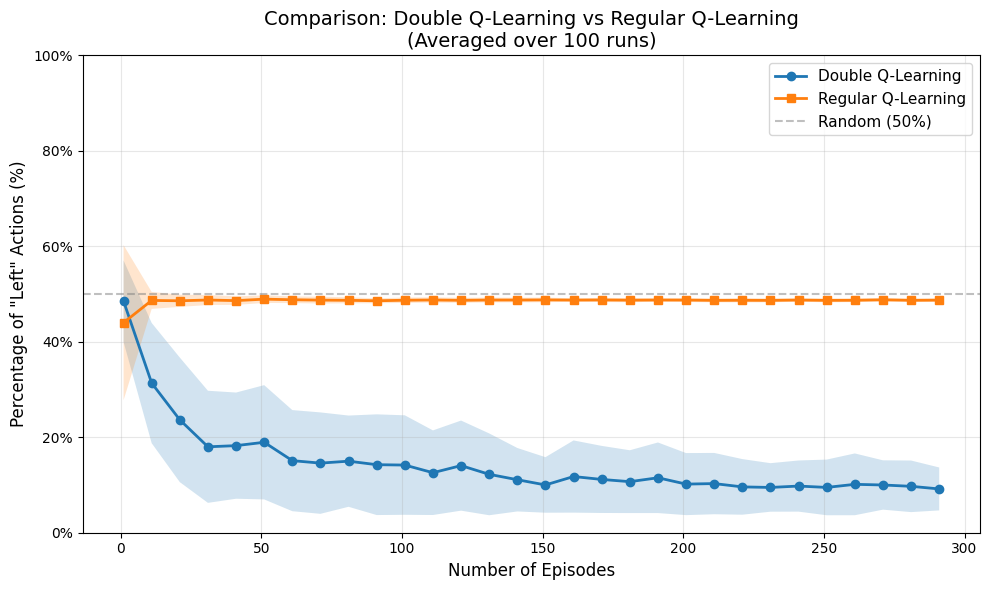


Final averages at 291 episodes:
Double Q-Learning: 9.2% left actions
Regular Q-Learning: 48.7% left actions


In [ ]:
# # Create the MDP
# example = Example67MDP(10)

# start_state = "A"
# alpha = 0.1
# gamma = 1
# epsilon = 0.1
# episodes = 100
# double_left = []
# q_left = []

# for ep in range(10, 300, 10):
#     # Run double Q-learning
#     Q1, Q2, left, right = double_q_learning(
#         mdp=example,
#         start_state=start_state,
#         alpha=alpha,
#         gamma=gamma,
#         epsilon=epsilon,
#         episodes=ep,
#         use_double=True
#     )
#     total_steps = left + right
#     left_percent = left / total_steps
#     double_left.append(left_percent)

#     # Display results
#     print("Double Q-Learning Results:")
#     print(f"State A - Q1 values: left={Q1[0][0]:.3f}, right={Q1[0][1]:.3f}")
#     print(f"State A - Q2 values: left={Q2[0][0]:.3f}, right={Q2[0][1]:.3f}")
#     print(f"State A - Avg values: left={(Q1[0][0]+Q2[0][0])/2:.3f}, right={(Q1[0][1]+Q2[0][1])/2:.3f}")

#     # Run double Q-learning
#     Q1, Q2, left, right = double_q_learning(
#         mdp=example,
#         start_state=start_state,
#         alpha=alpha,
#         gamma=gamma,
#         epsilon=epsilon,
#         episodes=ep,
#         use_double=False
#     )
#     total_steps = left + right
#     left_percent = left / total_steps
#     q_left.append(left_percent)

#     print("Q-Learning Results:")
#     print(f"State A - Q1 values: left={Q1[0][0]:.3f}, right={Q1[0][1]:.3f}")

#     import matplotlib.pyplot as plt

# # Episode counts (0, 10, 20, ..., 290)
# episode_counts = list(range(10, 300, 10))

# # Create the plot
# plt.figure(figsize=(10, 6))
# plt.plot(episode_counts, double_left, label='Double Q-Learning', marker='o', linewidth=2)
# plt.plot(episode_counts, q_left, label='Regular Q-Learning', marker='s', linewidth=2)

# # Add horizontal line at 50% (random choice)
# plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (50%)')

# # Labels and formatting
# plt.xlabel('Number of Episodes', fontsize=12)
# plt.ylabel('Percentage of "Left" Actions (%)', fontsize=12)
# plt.title('Comparison: Double Q-Learning vs Regular Q-Learning\n(Maximization Bias Demonstration)', fontsize=14)
# plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)

# # Set y-axis to percentage
# plt.ylim(0, 1)
# plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))

# plt.tight_layout()
# plt.show()
# Create the MDP
example = Example67MDP(1000)

start_state = "A"
alpha = 0.1
gamma = 1
epsilon = 0.1

# Number of runs to average over
num_runs = 10
episode_counts = list(range(1, 301, 10))

# Store results for all runs
all_double_left = []
all_q_left = []

for run in range(num_runs):
    print(f"Run {run + 1}/{num_runs}")
    double_left = []
    q_left = []
    
    for ep in episode_counts:
        # Run double Q-learning
        Q1, Q2, left, right = double_q_learning(
            mdp=example,
            start_state=start_state,
            alpha=alpha,
            gamma=gamma,
            epsilon=epsilon,
            episodes=ep,
            use_double=True
        )
        total_steps = left + right
        left_percent = left / total_steps
        double_left.append(left_percent)

        # Run regular Q-learning
        Q1, Q2, left, right = double_q_learning(
            mdp=example,
            start_state=start_state,
            alpha=alpha,
            gamma=gamma,
            epsilon=epsilon,
            episodes=ep,
            use_double=False
        )
        total_steps = left + right
        left_percent = left / total_steps
        q_left.append(left_percent)
    
    all_double_left.append(double_left)
    all_q_left.append(q_left)

# Calculate averages
avg_double_left = np.mean(all_double_left, axis=0)
avg_q_left = np.mean(all_q_left, axis=0)

# Optional: Calculate standard deviation for error bars
std_double_left = np.std(all_double_left, axis=0)
std_q_left = np.std(all_q_left, axis=0)

import matplotlib.pyplot as plt

# Create the plot with error bars
plt.figure(figsize=(10, 6))
plt.plot(episode_counts, avg_double_left, label='Double Q-Learning', marker='o', linewidth=2)
plt.fill_between(episode_counts, 
                  avg_double_left - std_double_left, 
                  avg_double_left + std_double_left, 
                  alpha=0.2)

plt.plot(episode_counts, avg_q_left, label='Regular Q-Learning', marker='s', linewidth=2)
plt.fill_between(episode_counts, 
                  avg_q_left - std_q_left, 
                  avg_q_left + std_q_left, 
                  alpha=0.2)

# Add horizontal line at 50% (random choice)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (50%)')

# Labels and formatting
plt.xlabel('Number of Episodes', fontsize=12)
plt.ylabel('Percentage of "Left" Actions (%)', fontsize=12)
plt.title(f'Comparison: Double Q-Learning vs Regular Q-Learning\n(Averaged over {num_runs} runs)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Set y-axis to percentage
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))

plt.tight_layout()
plt.show()

# Print final average values
print(f"\nFinal averages at {episode_counts[-1]} episodes:")
print(f"Double Q-Learning: {avg_double_left[-1]*100:.1f}% left actions")
print(f"Regular Q-Learning: {avg_q_left[-1]*100:.1f}% left actions")

In [ ]:
# def double_q_learning(world, start_state, alpha=0.5, gamma=0.9, epsilon=0.1, episodes=1000):
#     # Q1_table = np.full((world.width, world.height, len(ACTIONS)), 0.0) # Q1_table[x, y, a_idx]
#     # Q2_table = np.full((world.width, world.height, len(ACTIONS)), 0.0) # Q2_table[x, y, a_idx]
#     Q1_table = [[0 for _ in range(len(example.get_actions(state)))] for state in STATES]
#     Q2_table = [[0 for _ in range(len(example.get_actions(state)))] for state in STATES]

#     # policy = lambda state : np.argmax(Q1_table[*state, :] + Q2_table[*state, :]) \
#     #                         if random.random() >= epsilon \
#     #                         else random.randint(0, len(ACTIONS)-1)
#     def policy(state):
#         global example
#         actions = { a:epsilon/len(example.get_actions(state)) for a in example.get_actions(state) }
#         # Do a Q1 + Q2 to do epsilon greedy based on both tables:
#         Q = [sum(x) for x in zip(Q1_table[STATES.index(state)], Q2_table[STATES.index(state)])]
#         actions[example.get_actions(state)[np.argmax(Q)]] = 1 - epsilon + epsilon/len(example.get_actions(state))
#         return actions
    
#     for _ in range(episodes):
#         current_state = start_state
#         next_state = None

#         while not world.is_terminal(*current_state):
#             action_idx = policy(current_state)
#             next_state = world.get_next_state(current_state, ACTIONS[action_idx])
#             reward = world.get_reward(*next_state)
            
#             if random.random() >= 0.5:
#                 Q1_max_action_idx = np.argmax(Q1_table[*next_state, :]) # max(A_Q1_value)
#                 Q1_SA = Q1_table[*current_state, action_idx] # Q_1(S, A)
#                 Q1_TD_error = reward + gamma * Q2_table[*next_state, Q1_max_action_idx] - Q1_SA
#                 Q1_table[*current_state, action_idx] += alpha * Q1_TD_error
#             else:
#                 Q2_max_action_idx = np.argmax(Q2_table[*next_state, :]) # max(A_Q2_value)
#                 Q2_SA = Q2_table[*current_state, action_idx] # Q_1(S, A)
#                 Q2_TD_error = reward + gamma * Q1_table[*next_state, Q2_max_action_idx] - Q2_SA
#                 Q2_table[*current_state, action_idx] += alpha * Q2_TD_error

#             current_state = next_state

#     return Q1_table

## Comparison Tests: SARSA vs Q-Learning

In this section, we compare SARSA and Q-learning algorithms with different hyperparameters.

In [36]:
def test_alpha_comparison(alpha_values, num_runs=100, max_episodes=10000, epsilon=0.1, gamma=0.9):
    """
    Test 1: Compare SARSA and Q-learning with different alpha (learning rate) values.
    Shows how performance evolves during training from episode 1000 to max_episodes.
    
    Args:
        alpha_values: List of alpha values to test
        num_runs: Number of runs to average over
        max_episodes: Maximum number of training episodes
        epsilon: Exploration rate
        gamma: Discount factor
    
    Returns:
        Dictionary with results for each algorithm and alpha value
    """
    print("=" * 80)
    print("TEST 1: COMPARING SARSA vs Q-LEARNING WITH DIFFERENT ALPHA VALUES")
    print("=" * 80)
    print(f"Settings: {num_runs} runs, up to {max_episodes} episodes, ε={epsilon}, γ={gamma}")
    print()
    
    # Create a test world
    test_world = World(5, 5)
    test_world.add_terminal(4, 4, "+")
    start_state = (0, 0)
    
    # Episode checkpoints to sample (1000, 2000, ..., 10000)
    episode_checkpoints = list(range(1000, max_episodes + 1, 1000))
    
    results = {}
    
    # Create plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    for alpha in alpha_values:
        print(f"Testing α={alpha}...")
        
        # Store step counts for all runs at each checkpoint
        sarsa_checkpoint_steps = {ep: [] for ep in episode_checkpoints}
        qlearning_checkpoint_steps = {ep: [] for ep in episode_checkpoints}
        
        for run in range(num_runs):
            if (run + 1) % 10 == 0:
                print(f"  Run {run + 1}/{num_runs}")
            
            # Train SARSA and get step count for each episode
            Q_sarsa, steps_sarsa = sarsa(test_world, start_state, alpha=alpha, gamma=gamma, 
                           epsilon=epsilon, episodes=max_episodes)
            
            # Train Q-learning and get step count for each episode
            Q_qlearning, steps_qlearning = q_learning(test_world, start_state, alpha=alpha, gamma=gamma,
                                    epsilon=epsilon, episodes=max_episodes)
            
            # Sample at checkpoints (episode indices are 0-based, so checkpoint 1000 is index 999)
            for ep in episode_checkpoints:
                sarsa_checkpoint_steps[ep].append(steps_sarsa[ep - 1])
                qlearning_checkpoint_steps[ep].append(steps_qlearning[ep - 1])
        
        # Calculate average and std for each checkpoint
        sarsa_means = [np.mean(sarsa_checkpoint_steps[ep]) for ep in episode_checkpoints]
        sarsa_stds = [np.std(sarsa_checkpoint_steps[ep]) for ep in episode_checkpoints]
        qlearning_means = [np.mean(qlearning_checkpoint_steps[ep]) for ep in episode_checkpoints]
        qlearning_stds = [np.std(qlearning_checkpoint_steps[ep]) for ep in episode_checkpoints]
        
        # Store results
        results[f'SARSA_α={alpha}'] = {
            'means': sarsa_means,
            'stds': sarsa_stds,
            'alpha': alpha,
            'algorithm': 'SARSA'
        }
        results[f'Q-learning_α={alpha}'] = {
            'means': qlearning_means,
            'stds': qlearning_stds,
            'alpha': alpha,
            'algorithm': 'Q-learning'
        }
        
        print(f"  SARSA final (ep {max_episodes}):      {sarsa_means[-1]:.2f} ± {sarsa_stds[-1]:.2f} steps")
        print(f"  Q-learning final (ep {max_episodes}): {qlearning_means[-1]:.2f} ± {qlearning_stds[-1]:.2f} steps")
        print()
        
        # Plot SARSA results
        ax1.plot(episode_checkpoints, sarsa_means, marker='o', label=f'α={alpha}', linewidth=2)
        # ax1.fill_between(episode_checkpoints, 
        #                  np.array(sarsa_means) - np.array(sarsa_stds),
        #                  np.array(sarsa_means) + np.array(sarsa_stds),
        #                  alpha=0.2)
        
        # Plot Q-learning results
        ax2.plot(episode_checkpoints, qlearning_means, marker='s', label=f'α={alpha}', linewidth=2)
        # ax2.fill_between(episode_checkpoints,
        #                  np.array(qlearning_means) - np.array(qlearning_stds),
        #                  np.array(qlearning_means) + np.array(qlearning_stds),
        #                  alpha=0.2)
    
    # Format SARSA plot
    ax1.set_xlabel('Episode Number', fontsize=12)
    ax1.set_ylabel('Average Steps per Episode', fontsize=12)
    ax1.set_title('SARSA: Learning Performance vs Episodes\n(Different Learning Rates α)', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Format Q-learning plot
    ax2.set_xlabel('Episode Number', fontsize=12)
    ax2.set_ylabel('Average Steps per Episode', fontsize=12)
    ax2.set_title('Q-Learning: Learning Performance vs Episodes\n(Different Learning Rates α)', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results

In [ ]:
def test_epsilon_comparison(epsilon_values, num_runs=100, max_episodes=10000, alpha=0.5, gamma=0.9):
    """
    Test 2: Compare SARSA and Q-learning with different epsilon (exploration rate) values.
    Shows how performance evolves during training from episode 1000 to max_episodes.
    
    Args:
        epsilon_values: List of epsilon values to test
        num_runs: Number of runs to average over
        max_episodes: Maximum number of training episodes
        alpha: Learning rate
        gamma: Discount factor
    
    Returns:
        Dictionary with results for each algorithm and epsilon value
    """
    print("=" * 80)
    print("TEST 2: COMPARING SARSA vs Q-LEARNING WITH DIFFERENT EPSILON VALUES")
    print("=" * 80)
    print(f"Settings: {num_runs} runs, up to {max_episodes} episodes, α={alpha}, γ={gamma}")
    print()
    
    # Create a test world
    test_world = World(5, 5)
    test_world.add_terminal(4, 4, "+")
    start_state = (0, 0)
    
    # Episode checkpoints to sample (1000, 2000, ..., 10000)
    episode_checkpoints = list(range(1000, max_episodes + 1, 1000))
    
    results = {}
    
    # Create plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    for epsilon in epsilon_values:
        print(f"Testing ε={epsilon}...")
        
        # Store step counts for all runs at each checkpoint
        sarsa_checkpoint_steps = {ep: [] for ep in episode_checkpoints}
        qlearning_checkpoint_steps = {ep: [] for ep in episode_checkpoints}
        
        for run in range(num_runs):
            if (run + 1) % 10 == 0:
                print(f"  Run {run + 1}/{num_runs}")
            
            # Train SARSA and get step count for each episode
            Q_sarsa, steps_sarsa = sarsa(test_world, start_state, alpha=alpha, gamma=gamma, 
                           epsilon=epsilon, episodes=max_episodes)
            
            # Train Q-learning and get step count for each episode
            Q_qlearning, steps_qlearning = q_learning(test_world, start_state, alpha=alpha, gamma=gamma,
                                    epsilon=epsilon, episodes=max_episodes)
            
            # Sample at checkpoints (episode indices are 0-based, so checkpoint 1000 is index 999)
            for ep in episode_checkpoints:
                sarsa_checkpoint_steps[ep].append(steps_sarsa[ep - 1])
                qlearning_checkpoint_steps[ep].append(steps_qlearning[ep - 1])
        
        # Calculate average and std for each checkpoint
        sarsa_means = [np.mean(sarsa_checkpoint_steps[ep]) for ep in episode_checkpoints]
        sarsa_stds = [np.std(sarsa_checkpoint_steps[ep]) for ep in episode_checkpoints]
        qlearning_means = [np.mean(qlearning_checkpoint_steps[ep]) for ep in episode_checkpoints]
        qlearning_stds = [np.std(qlearning_checkpoint_steps[ep]) for ep in episode_checkpoints]
        
        # Store results
        results[f'SARSA_ε={epsilon}'] = {
            'means': sarsa_means,
            'stds': sarsa_stds,
            'epsilon': epsilon,
            'algorithm': 'SARSA'
        }
        results[f'Q-learning_ε={epsilon}'] = {
            'means': qlearning_means,
            'stds': qlearning_stds,
            'epsilon': epsilon,
            'algorithm': 'Q-learning'
        }
        
        print(f"  SARSA final (ep {max_episodes}):      {sarsa_means[-1]:.2f} ± {sarsa_stds[-1]:.2f} steps")
        print(f"  Q-learning final (ep {max_episodes}): {qlearning_means[-1]:.2f} ± {qlearning_stds[-1]:.2f} steps")
        print()
        
        # Plot SARSA results
        ax1.plot(episode_checkpoints, sarsa_means, marker='o', label=f'ε={epsilon}', linewidth=2)
        # ax1.fill_between(episode_checkpoints, 
        #                  np.array(sarsa_means) - np.array(sarsa_stds),
        #                  np.array(sarsa_means) + np.array(sarsa_stds),
        #                  alpha=0.2)
        
        # Plot Q-learning results
        ax2.plot(episode_checkpoints, qlearning_means, marker='s', label=f'ε={epsilon}', linewidth=2)
        # ax2.fill_between(episode_checkpoints,
        #                  np.array(qlearning_means) - np.array(qlearning_stds),
        #                  np.array(qlearning_means) + np.array(qlearning_stds),
        #                  alpha=0.2)
    
    # Format SARSA plot
    ax1.set_xlabel('Episode Number', fontsize=12)
    ax1.set_ylabel('Average Steps per Episode', fontsize=12)
    ax1.set_title('SARSA: Learning Performance vs Episodes\n(Different Exploration Rates ε)', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Format Q-learning plot
    ax2.set_xlabel('Episode Number', fontsize=12)
    ax2.set_ylabel('Average Steps per Episode', fontsize=12)
    ax2.set_title('Q-Learning: Learning Performance vs Episodes\n(Different Exploration Rates ε)', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results

### Run the tests

TEST 1: COMPARING SARSA vs Q-LEARNING WITH DIFFERENT ALPHA VALUES
Settings: 100 runs, up to 10000 episodes, ε=0.1, γ=0.9

Testing α=0.1...
  Run 10/100
  Run 20/100
  Run 30/100
  Run 40/100
  Run 50/100
  Run 60/100
  Run 70/100
  Run 80/100
  Run 90/100
  Run 100/100
  SARSA final (ep 10000):      8.78 ± 1.31 steps
  Q-learning final (ep 10000): 8.75 ± 1.19 steps

Testing α=0.3...
  Run 10/100
  Run 20/100
  Run 30/100
  Run 40/100
  Run 50/100
  Run 60/100
  Run 70/100
  Run 80/100
  Run 90/100
  Run 100/100
  SARSA final (ep 10000):      8.78 ± 1.17 steps
  Q-learning final (ep 10000): 9.04 ± 1.68 steps

Testing α=0.5...
  Run 10/100
  Run 20/100
  Run 30/100
  Run 40/100
  Run 50/100
  Run 60/100
  Run 70/100
  Run 80/100
  Run 90/100
  Run 100/100
  SARSA final (ep 10000):      8.98 ± 1.42 steps
  Q-learning final (ep 10000): 9.08 ± 1.61 steps

Testing α=0.7...
  Run 10/100
  Run 20/100
  Run 30/100
  Run 40/100
  Run 50/100
  Run 60/100
  Run 70/100
  Run 80/100
  Run 90/100
  R

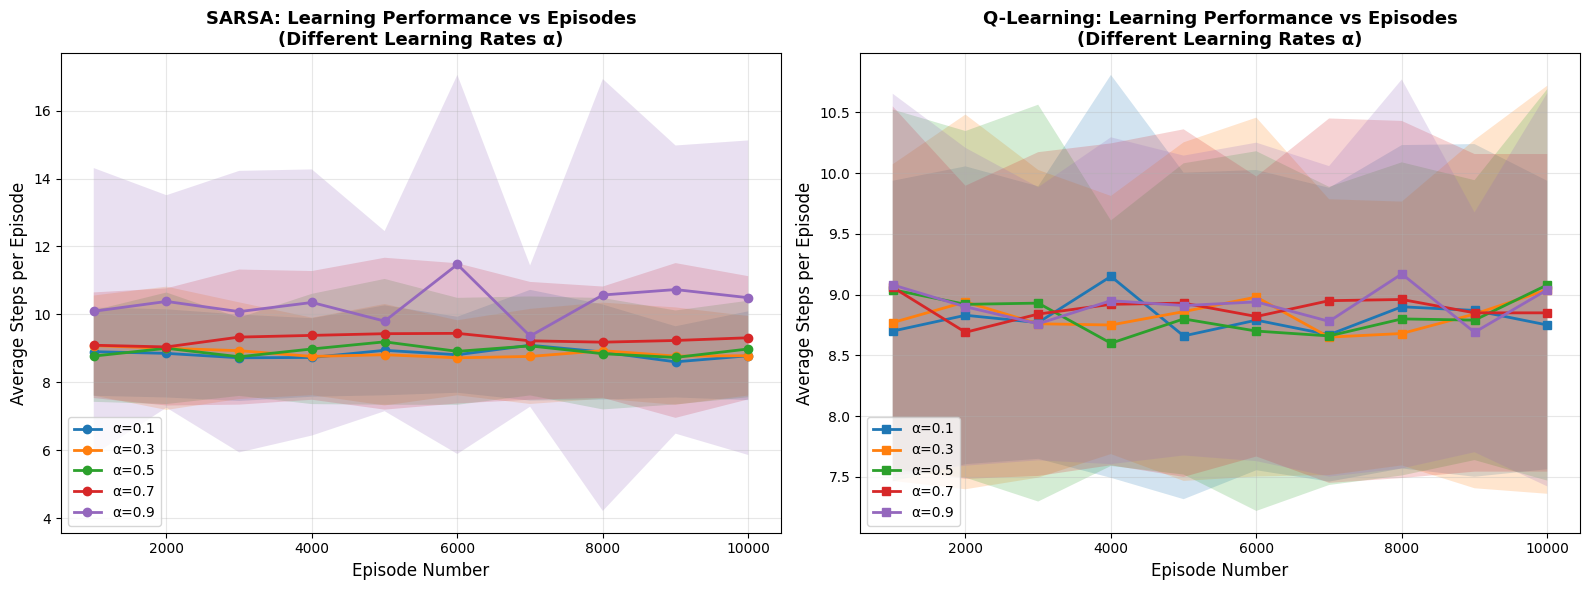


ALPHA TEST SUMMARY (Final Episode Performance)
Q-learning_α=0.1    :   8.75 ±  1.19 steps
Q-learning_α=0.3    :   9.04 ±  1.68 steps
Q-learning_α=0.5    :   9.08 ±  1.61 steps
Q-learning_α=0.7    :   8.85 ±  1.31 steps
Q-learning_α=0.9    :   9.04 ±  1.62 steps
SARSA_α=0.1         :   8.78 ±  1.31 steps
SARSA_α=0.3         :   8.78 ±  1.17 steps
SARSA_α=0.5         :   8.98 ±  1.42 steps
SARSA_α=0.7         :   9.31 ±  1.81 steps
SARSA_α=0.9         :  10.49 ±  4.63 steps


In [35]:
# Test 1: Compare different alpha values
alpha_values = [0.1, 0.3, 0.5, 0.7, 0.9]
alpha_results = test_alpha_comparison(alpha_values, num_runs=100, max_episodes=10000)

print("\n" + "=" * 80)
print("ALPHA TEST SUMMARY (Final Episode Performance)")
print("=" * 80)
for key in sorted(alpha_results.keys()):
    result = alpha_results[key]
    final_mean = result['means'][-1]
    final_std = result['stds'][-1]
    print(f"{key:20s}: {final_mean:6.2f} ± {final_std:5.2f} steps")

TEST 2: COMPARING SARSA vs Q-LEARNING WITH DIFFERENT EPSILON VALUES
Settings: 100 runs, up to 10000 episodes, α=0.5, γ=0.9

Testing ε=0.05...
  Run 10/100
  Run 20/100
  Run 30/100
  Run 40/100
  Run 50/100
  Run 60/100
  Run 70/100
  Run 80/100
  Run 90/100
  Run 100/100
  SARSA final (ep 10000):      8.46 ± 0.94 steps
  Q-learning final (ep 10000): 8.45 ± 0.98 steps

Testing ε=0.1...
  Run 10/100
  Run 20/100
  Run 30/100
  Run 40/100
  Run 50/100
  Run 60/100
  Run 70/100
  Run 80/100
  Run 90/100
  Run 100/100
  SARSA final (ep 10000):      8.86 ± 1.72 steps
  Q-learning final (ep 10000): 8.96 ± 1.48 steps

Testing ε=0.2...
  Run 10/100
  Run 20/100
  Run 30/100
  Run 40/100
  Run 50/100
  Run 60/100
  Run 70/100
  Run 80/100
  Run 90/100
  Run 100/100
  SARSA final (ep 10000):      10.05 ± 2.16 steps
  Q-learning final (ep 10000): 9.88 ± 2.22 steps

Testing ε=0.3...
  Run 10/100
  Run 20/100
  Run 30/100
  Run 40/100
  Run 50/100
  Run 60/100
  Run 70/100
  Run 80/100
  Run 90/100

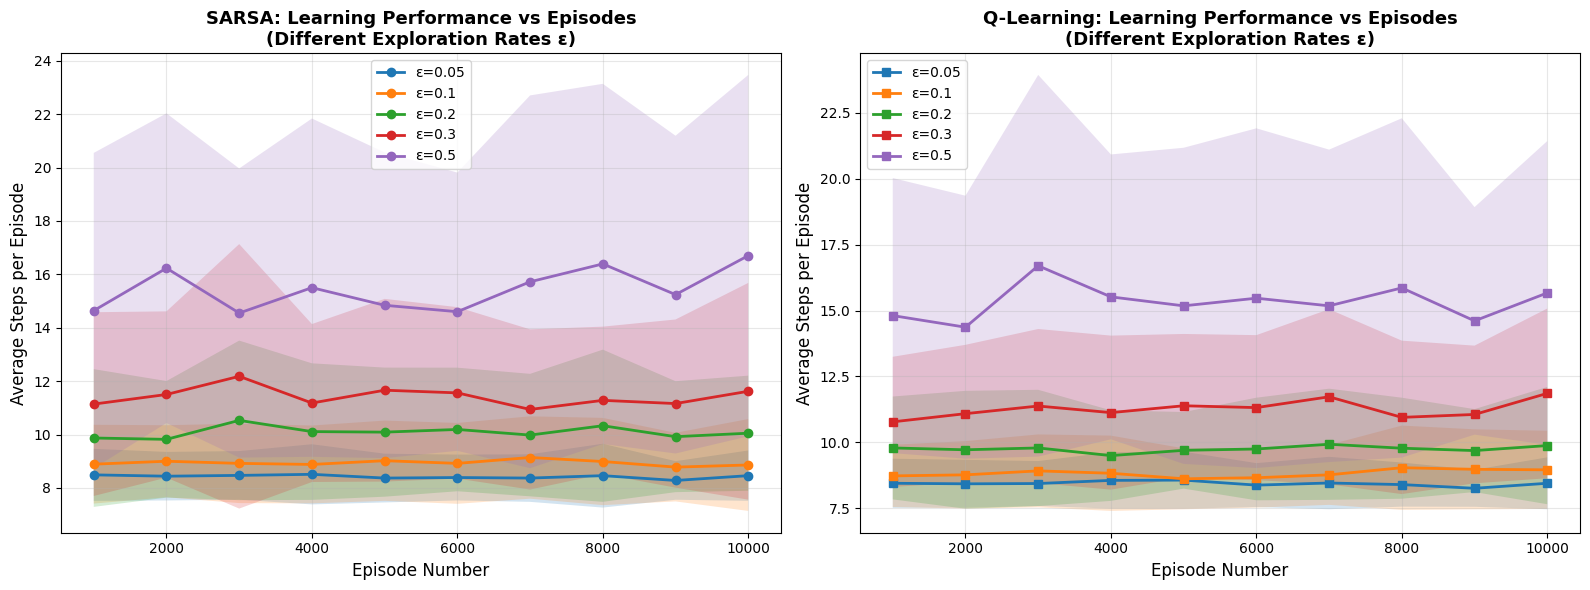


EPSILON TEST SUMMARY (Final Episode Performance)
Q-learning_ε=0.05   :   8.45 ±  0.98 steps
Q-learning_ε=0.1    :   8.96 ±  1.48 steps
Q-learning_ε=0.2    :   9.88 ±  2.22 steps
Q-learning_ε=0.3    :  11.86 ±  3.22 steps
Q-learning_ε=0.5    :  15.67 ±  5.76 steps
SARSA_ε=0.05        :   8.46 ±  0.94 steps
SARSA_ε=0.1         :   8.86 ±  1.72 steps
SARSA_ε=0.2         :  10.05 ±  2.16 steps
SARSA_ε=0.3         :  11.62 ±  4.06 steps
SARSA_ε=0.5         :  16.70 ±  6.77 steps


In [37]:
# Test 2: Compare different epsilon values
epsilon_values = [0.05, 0.1, 0.2, 0.3, 0.5]
epsilon_results = test_epsilon_comparison(epsilon_values, num_runs=100, max_episodes=10000)

print("\n" + "=" * 80)
print("EPSILON TEST SUMMARY (Final Episode Performance)")
print("=" * 80)
for key in sorted(epsilon_results.keys()):
    result = epsilon_results[key]
    final_mean = result['means'][-1]
    final_std = result['stds'][-1]
    print(f"{key:20s}: {final_mean:6.2f} ± {final_std:5.2f} steps")